<a href="https://colab.research.google.com/github/samarjeet621/Machine_Learning_Project/blob/Develop/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
from google.colab import files
uploaded = files.upload()

Saving Data.csv to Data (1).csv


In [16]:
import pandas as pd

In [17]:
housing = pd.read_csv("Data.csv")

In [18]:
housing.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [19]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       501 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [20]:
housing['CHAS'].value_counts()

,count
CHAS,
0,471
1,35


In [28]:
import numpy as np
def split_train_test(data, test_ratio):
  np.random.seed(42)
  shuffled = np.random.permutation(len(data))
  test_set_size = int(len(data) * test_ratio)
  test_indices = shuffled[:test_set_size]
  train_indices = shuffled[test_set_size:]
  return data.iloc[test_indices], data.iloc[train_indices]

In [29]:
train_set, test_set = split_train_test(housing, 0.2)

In [30]:
print(f"row in train set: {len(train_set)}\nRow in test set: {len(test_set)}")
# print(housing.value_counts())

row in train set: 101
Row in test set: 405


In [31]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)
print(f"Train set size: {len(train_set)}\nRow Test set size: {len(test_set)}")

Train set size: 404
Row Test set size: 102


In [33]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing['CHAS']):
  strat_train_set = housing.loc[train_index]
  strat_test_set = housing.loc[test_index]


In [34]:
strat_train_set['CHAS'].value_counts()

,count
CHAS,
0,376
1,28


In [35]:
strat_test_set['CHAS'].value_counts()

,count
CHAS,
0,95
1,7


In [36]:
376/28, 95/7

(13.428571428571429, 13.571428571428571)

In [37]:
housing = strat_train_set.copy()

In [41]:
corr_matrix = housing.corr()
corr_matrix['MEDV'].sort_values(ascending=False)

,MEDV
MEDV,1.000000
RM,0.678696
B,0.361761
ZN,0.339741
DIS,0.240451
CHAS,0.205066
AGE,-0.364596
RAD,-0.374693
CRIM,-0.393715
NOX,-0.422873


array([[<Axes: xlabel='MEDV', ylabel='MEDV'>,
        <Axes: xlabel='RM', ylabel='MEDV'>,
        <Axes: xlabel='ZN', ylabel='MEDV'>,
        <Axes: xlabel='LSTAT', ylabel='MEDV'>],
       [<Axes: xlabel='MEDV', ylabel='RM'>,
        <Axes: xlabel='RM', ylabel='RM'>,
        <Axes: xlabel='ZN', ylabel='RM'>,
        <Axes: xlabel='LSTAT', ylabel='RM'>],
       [<Axes: xlabel='MEDV', ylabel='ZN'>,
        <Axes: xlabel='RM', ylabel='ZN'>,
        <Axes: xlabel='ZN', ylabel='ZN'>,
        <Axes: xlabel='LSTAT', ylabel='ZN'>],
       [<Axes: xlabel='MEDV', ylabel='LSTAT'>,
        <Axes: xlabel='RM', ylabel='LSTAT'>,
        <Axes: xlabel='ZN', ylabel='LSTAT'>,
        <Axes: xlabel='LSTAT', ylabel='LSTAT'>]], dtype=object)

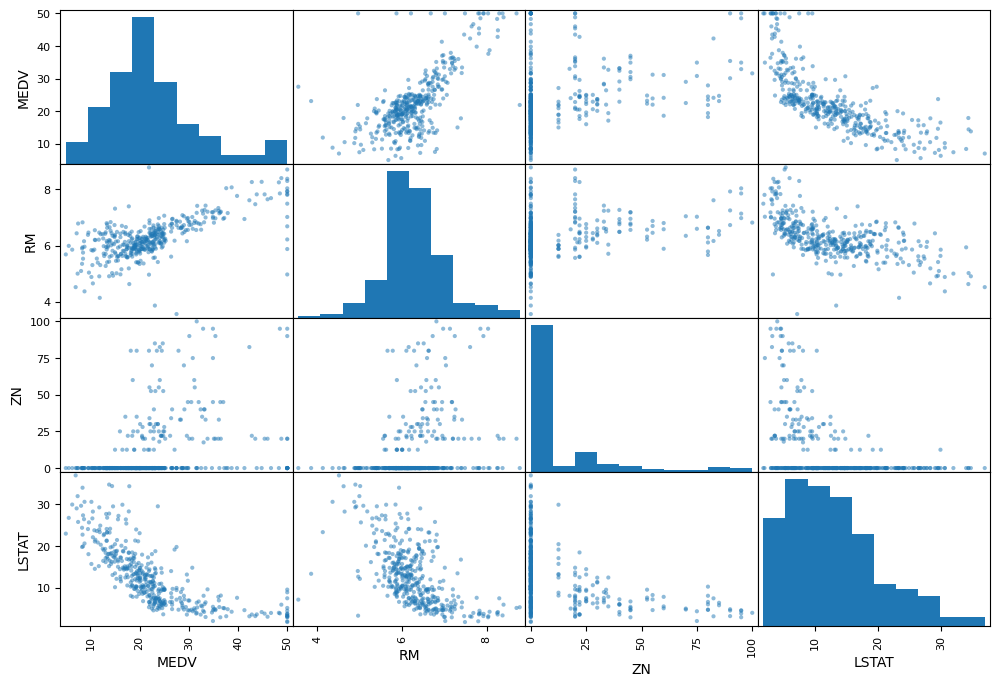

In [42]:
from pandas.plotting import scatter_matrix
attribute = ['MEDV', 'RM', 'ZN', 'LSTAT']
scatter_matrix(housing[attribute], figsize=(12, 8))

<Axes: xlabel='RM', ylabel='MEDV'>

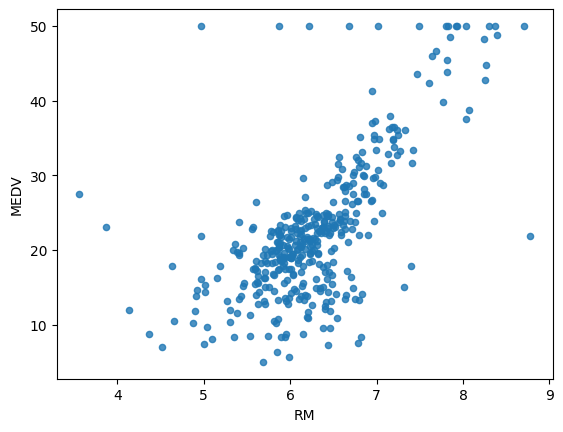

In [43]:
housing.plot(kind='scatter', x='RM', y = 'MEDV', alpha=0.8)

In [44]:
housing['TAX_RM'] = housing['TAX']/housing['RM']
housing.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,TAX_RM
254,0.04819,80.0,3.64,0,0.392,6.108,32.0,9.2203,1,315,16.4,392.89,6.57,21.9,51.571709
348,0.01501,80.0,2.01,0,0.435,6.635,29.7,8.3440,4,280,17.0,390.94,5.99,24.5,42.200452
476,4.87141,0.0,18.10,0,0.614,6.484,93.6,2.3053,24,666,20.2,396.21,18.68,16.7,102.714374
321,0.18159,0.0,7.38,0,0.493,6.376,54.3,4.5404,5,287,19.6,396.90,6.87,23.1,45.012547
326,0.30347,0.0,7.38,0,0.493,6.312,28.9,5.4159,5,287,19.6,396.90,6.15,23.0,45.468948


In [47]:
housing = strat_train_set.drop('MEDV', axis=1)
housing_labels = strat_train_set['MEDV'].copy()

In [49]:
housing.head() #MEDV removed for labels

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
254,0.04819,80.0,3.64,0,0.392,6.108,32.0,9.2203,1,315,16.4,392.89,6.57
348,0.01501,80.0,2.01,0,0.435,6.635,29.7,8.3440,4,280,17.0,390.94,5.99
476,4.87141,0.0,18.10,0,0.614,6.484,93.6,2.3053,24,666,20.2,396.21,18.68
321,0.18159,0.0,7.38,0,0.493,6.376,54.3,4.5404,5,287,19.6,396.90,6.87
326,0.30347,0.0,7.38,0,0.493,6.312,28.9,5.4159,5,287,19.6,396.90,6.15


In [50]:
housing_labels.head()

,MEDV
254,21.9
348,24.5
476,16.7
321,23.1
326,23.0


In [59]:
missing_column = housing.dropna(subset=['RM'])

In [60]:
missing_column.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
count,401.000000,401.000000,401.000000,401.000000,401.000000,401.000000,401.000000,401.000000,401.000000,401.000000,401.000000,401.000000,401.000000
mean,3.629127,10.811721,11.386633,0.069825,0.559041,6.278855,69.226434,3.720033,9.770574,413.418953,18.468080,353.113766,12.817681
std,8.123947,22.213146,6.878363,0.255171,0.116750,0.713923,28.186666,2.080196,8.752270,168.808498,2.136008,96.373328,7.252533
min,0.006320,0.000000,0.740000,0.000000,0.389000,3.561000,2.900000,1.129600,1.000000,187.000000,13.000000,0.320000,1.730000
25%,0.087070,0.000000,5.320000,0.000000,0.453000,5.879000,45.000000,2.021800,4.000000,284.000000,17.400000,374.430000,6.870000
50%,0.289600,0.000000,9.900000,0.000000,0.538000,6.209000,78.700000,3.102500,5.000000,345.000000,19.000000,390.950000,11.640000
75%,3.836840,12.500000,18.100000,0.000000,0.631000,6.630000,94.100000,4.967100,24.000000,666.000000,20.200000,395.630000,17.110000
max,73.534100,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,36.980000


In [56]:
# missing_columns = housing.isnull().sum()

# print(missing_columns[missing_columns > 0])

In [58]:
housing.drop('RM', axis=1).shape

(404, 12)

In [61]:
median = housing['RM'].median()

In [62]:
housing['RM'].fillna(median)

,RM
254,6.108
348,6.635
476,6.484
321,6.376
326,6.312
...,...
155,6.152
423,6.103
98,7.820
455,6.525


In [64]:
housing.shape

(404, 13)

In [65]:
from warnings import simplefilter
from sklearn.impute import SimpleImputer
impute = SimpleImputer(strategy="median")
impute.fit(housing)

SimpleImputer(strategy='median')

In [66]:
impute.statistics_

array([2.86735e-01, 0.00000e+00, 9.90000e+00, 0.00000e+00, 5.38000e-01,
       6.20900e+00, 7.82000e+01, 3.12220e+00, 5.00000e+00, 3.37000e+02,
       1.90000e+01, 3.90955e+02, 1.15700e+01])

In [67]:
x = impute.transform(housing)

In [68]:
housing_tr = pd.DataFrame(x, columns=housing.columns)

In [69]:
housing_tr.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
count,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000
mean,3.602814,10.836634,11.344950,0.069307,0.558064,6.278337,69.039851,3.746210,9.735149,412.341584,18.473267,353.392822,12.791609
std,8.099383,22.150636,6.877817,0.254290,0.116875,0.711286,28.258248,2.099057,8.731259,168.672623,2.129243,96.069235,7.235740
min,0.006320,0.000000,0.740000,0.000000,0.389000,3.561000,2.900000,1.129600,1.000000,187.000000,13.000000,0.320000,1.730000
25%,0.086962,0.000000,5.190000,0.000000,0.453000,5.879750,44.850000,2.035975,4.000000,284.000000,17.400000,374.617500,6.847500
50%,0.286735,0.000000,9.900000,0.000000,0.538000,6.209000,78.200000,3.122200,5.000000,337.000000,19.000000,390.955000,11.570000
75%,3.731923,12.500000,18.100000,0.000000,0.631000,6.630000,94.100000,5.100400,24.000000,666.000000,20.200000,395.630000,17.102500
max,73.534100,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,36.980000


In [74]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
my_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    #.....add as many as you want in your pipeline
    ('std_scaler', StandardScaler())
])
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# my_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('std_scaler', StandardScaler)])

In [77]:
housing_num_tr = my_pipeline.fit_transform(housing)

In [79]:
housing_num_tr.shape

(404, 13)

In [110]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
modal  = RandomForestRegressor()
modal.fit(housing_num_tr, housing_labels)

RandomForestRegressor()

In [111]:
some_data = housing.loc[:5]

In [113]:
some_labels = housing_labels.loc[:5]

In [114]:
preparated_data = my_pipeline.transform(some_data)

In [115]:
modal.predict(preparated_data)

array([22.216, 26.185, 16.23 , 23.307, 23.482, 16.449, 24.442, 26.329,
       10.628, 31.292, 16.2  , 18.161, 10.533, 34.314, 23.301, 13.953,
       18.819, 17.482,  6.754, 20.394, 18.909, 16.076, 17.887, 26.004,
       24.121, 24.813, 13.476, 20.89 , 14.825, 27.955, 14.357, 18.219,
       11.25 , 13.112, 20.644, 26.985, 23.583, 47.512, 32.725, 19.936,
       21.816, 34.952, 37.111,  9.601, 19.979, 12.382, 21.706, 26.007,
       22.72 ,  7.958, 24.653, 23.09 , 23.761, 30.28 , 14.826, 38.552,
       21.679, 24.957, 33.982, 18.103, 19.839, 19.867, 27.989, 20.952,
       14.358, 31.209, 49.51 , 14.571, 26.53 , 34.771, 22.518, 36.126,
       23.33 , 10.152, 20.518, 27.318, 26.01 , 15.051, 16.557, 18.982,
       30.584,  8.666, 19.558, 19.456, 24.935, 23.025, 30.342, 25.033,
       29.915, 16.467, 23.186, 30.083, 28.055, 20.181, 21.763, 34.562,
       33.808, 19.809, 23.1  , 17.007, 12.546, 46.341, 20.218, 43.571,
       17.078, 15.809, 19.805, 21.603, 27.285, 16.419, 17.574,  7.839,
      

In [116]:
list(some_labels)

[21.9,
 24.5,
 16.7,
 23.1,
 23.0,
 17.2,
 24.4,
 27.5,
 9.5,
 31.6,
 16.3,
 18.3,
 8.1,
 34.9,
 24.5,
 13.4,
 18.7,
 19.1,
 5.6,
 20.5,
 19.6,
 17.2,
 17.4,
 27.5,
 23.9,
 25.0,
 12.7,
 21.2,
 14.8,
 29.0,
 14.0,
 16.6,
 11.3,
 13.3,
 21.9,
 29.6,
 23.4,
 50.0,
 31.7,
 20.4,
 21.4,
 34.9,
 37.9,
 10.4,
 20.1,
 13.8,
 21.7,
 25.0,
 22.2,
 7.0,
 24.8,
 22.8,
 23.8,
 28.7,
 14.3,
 41.3,
 21.7,
 23.9,
 32.9,
 16.1,
 19.5,
 19.9,
 28.4,
 21.0,
 13.8,
 31.6,
 50.0,
 14.5,
 26.6,
 35.4,
 22.0,
 36.5,
 22.4,
 10.5,
 20.1,
 29.8,
 24.0,
 15.2,
 16.1,
 18.5,
 29.6,
 7.5,
 19.3,
 18.7,
 24.8,
 27.5,
 30.5,
 25.3,
 29.8,
 17.9,
 22.9,
 30.1,
 27.9,
 20.4,
 21.7,
 33.4,
 21.9,
 19.0,
 22.0,
 19.1,
 13.9,
 45.4,
 20.3,
 42.3,
 16.0,
 15.6,
 20.5,
 22.7,
 29.1,
 17.8,
 15.0,
 7.2,
 15.1,
 20.6,
 11.8,
 19.1,
 13.1,
 37.2,
 23.3,
 15.2,
 23.1,
 8.5,
 8.3,
 19.3,
 24.1,
 14.6,
 14.1,
 25.0,
 11.7,
 21.2,
 22.9,
 11.8,
 16.8,
 11.9,
 50.0,
 17.1,
 23.7,
 23.9,
 22.5,
 50.0,
 14.9,
 22.6,
 28.6,
 18.8,


In [117]:
from sklearn.metrics import mean_squared_error
housing_predictions = modal.predict(housing_num_tr)
msc = mean_squared_error(housing_labels, housing_predictions)
rmse = np.sqrt(msc)
# from sklearn.metrics import mean_squared_error
# housing_predict = modal.predict(housing_num_tr)
# msc = mean_squared_error(housing_labels, housing_predict)
# rmse = np.sqrt(msc)

In [118]:
rmse

np.float64(1.359757231171348)

In [119]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(modal, housing_num_tr, housing_labels, scoring="neg_mean_squared_error", cv=10)
rmse_scores = np.sqrt(-scores)
# from sklearn.model_selection import cross_val_score
# scores = cross_val_score(modal, housing_num_tr, housing_labels, scoring="neg_mean_squared_error", cv=10)
# rmse_scores = np.sqrt(-scores)

In [120]:
rmse_scores

array([2.6920546 , 2.78878482, 4.39514902, 2.53612951, 3.54801069,
       2.58638476, 4.93060175, 3.34982163, 2.96140047, 3.44074523])

In [121]:
def print_scores(scores):
  print("Scores: ", scores)
  print("Mean: ", scores.mean())
  print("Standard divition: ", scores.std())


In [122]:
print_scores(rmse_scores)

Scores:  [2.6920546  2.78878482 4.39514902 2.53612951 3.54801069 2.58638476
 4.93060175 3.34982163 2.96140047 3.44074523]
Mean:  3.3229082481441607
Standard divition:  0.7599407414884649
